In [1]:
import pandas as pd

In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/Amitmakode/X_DSAAI_B8/refs/heads/main/Machine_Learning/16.%20Admission_Predict.csv?token=GHSAT0AAAAAADN6CAG3NXVRTHXQE7ZVVL722N2FLUA")

In [4]:
df.isnull().sum()

Serial No.           0
GRE Score            0
TOEFL Score          0
University Rating    0
SOP                  0
LOR                  0
CGPA                 0
Research             0
Chance of Admit      0
dtype: int64

In [5]:
df.duplicated().sum()

0

In [6]:
df.shape

(400, 9)

In [11]:
df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [14]:
df.dtypes

Serial No.             int64
GRE Score              int64
TOEFL Score            int64
University Rating      int64
SOP                  float64
LOR                  float64
CGPA                 float64
Research               int64
Chance of Admit      float64
dtype: object

In [15]:
df["Chance of Admit "]

0      0.92
1      0.76
2      0.72
3      0.80
4      0.65
       ... 
395    0.82
396    0.84
397    0.91
398    0.67
399    0.95
Name: Chance of Admit , Length: 400, dtype: float64

In [17]:
df = df.iloc[:, 1:]

In [19]:
X = df.drop("Chance of Admit ", axis=1)

In [20]:
X.head(2)

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research
0,337,118,4,4.5,4.5,9.65,1
1,324,107,4,4.0,4.5,8.87,1


In [21]:
y = df["Chance of Admit "]

In [22]:
y

0      0.92
1      0.76
2      0.72
3      0.80
4      0.65
       ... 
395    0.82
396    0.84
397    0.91
398    0.67
399    0.95
Name: Chance of Admit , Length: 400, dtype: float64

In [23]:
from sklearn.model_selection import train_test_split

In [24]:
x_train, x_test, y_train, y_test = train_test_split(X,y, test_size=0.25, random_state=42)

In [25]:
from sklearn.tree import DecisionTreeRegressor

In [26]:
dt= DecisionTreeRegressor()

In [27]:
dt.fit(x_train,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [28]:
y_pred = dt.predict(x_test)

In [29]:
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score

In [30]:
mean_absolute_error(y_test,y_pred)

0.06210000000000001

In [31]:
r2_score(y_test,y_pred)

0.6718233649733395

In [32]:
from sklearn import tree

In [33]:
import matplotlib.pyplot as plt

[Text(0.519375, 0.9285714285714286, 'x[5] <= 8.735\nsquared_error = 0.019\nsamples = 300\nvalue = 0.726'),
 Text(0.25625, 0.7857142857142857, 'x[5] <= 8.11\nsquared_error = 0.011\nsamples = 174\nvalue = 0.643'),
 Text(0.3878125, 0.8571428571428572, 'True  '),
 Text(0.125, 0.6428571428571429, 'x[5] <= 7.665\nsquared_error = 0.01\nsamples = 64\nvalue = 0.559'),
 Text(0.055, 0.5, 'x[0] <= 305.5\nsquared_error = 0.006\nsamples = 22\nvalue = 0.495'),
 Text(0.03, 0.35714285714285715, 'x[5] <= 7.655\nsquared_error = 0.004\nsamples = 17\nvalue = 0.471'),
 Text(0.02, 0.21428571428571427, 'x[5] <= 7.0\nsquared_error = 0.003\nsamples = 15\nvalue = 0.483'),
 Text(0.01, 0.07142857142857142, '\n  (...)  \n'),
 Text(0.03, 0.07142857142857142, '\n  (...)  \n'),
 Text(0.04, 0.21428571428571427, 'squared_error = 0.0\nsamples = 2\nvalue = 0.38'),
 Text(0.08, 0.35714285714285715, 'x[3] <= 2.0\nsquared_error = 0.005\nsamples = 5\nvalue = 0.576'),
 Text(0.06, 0.21428571428571427, 'x[0] <= 313.5\nsquared_err

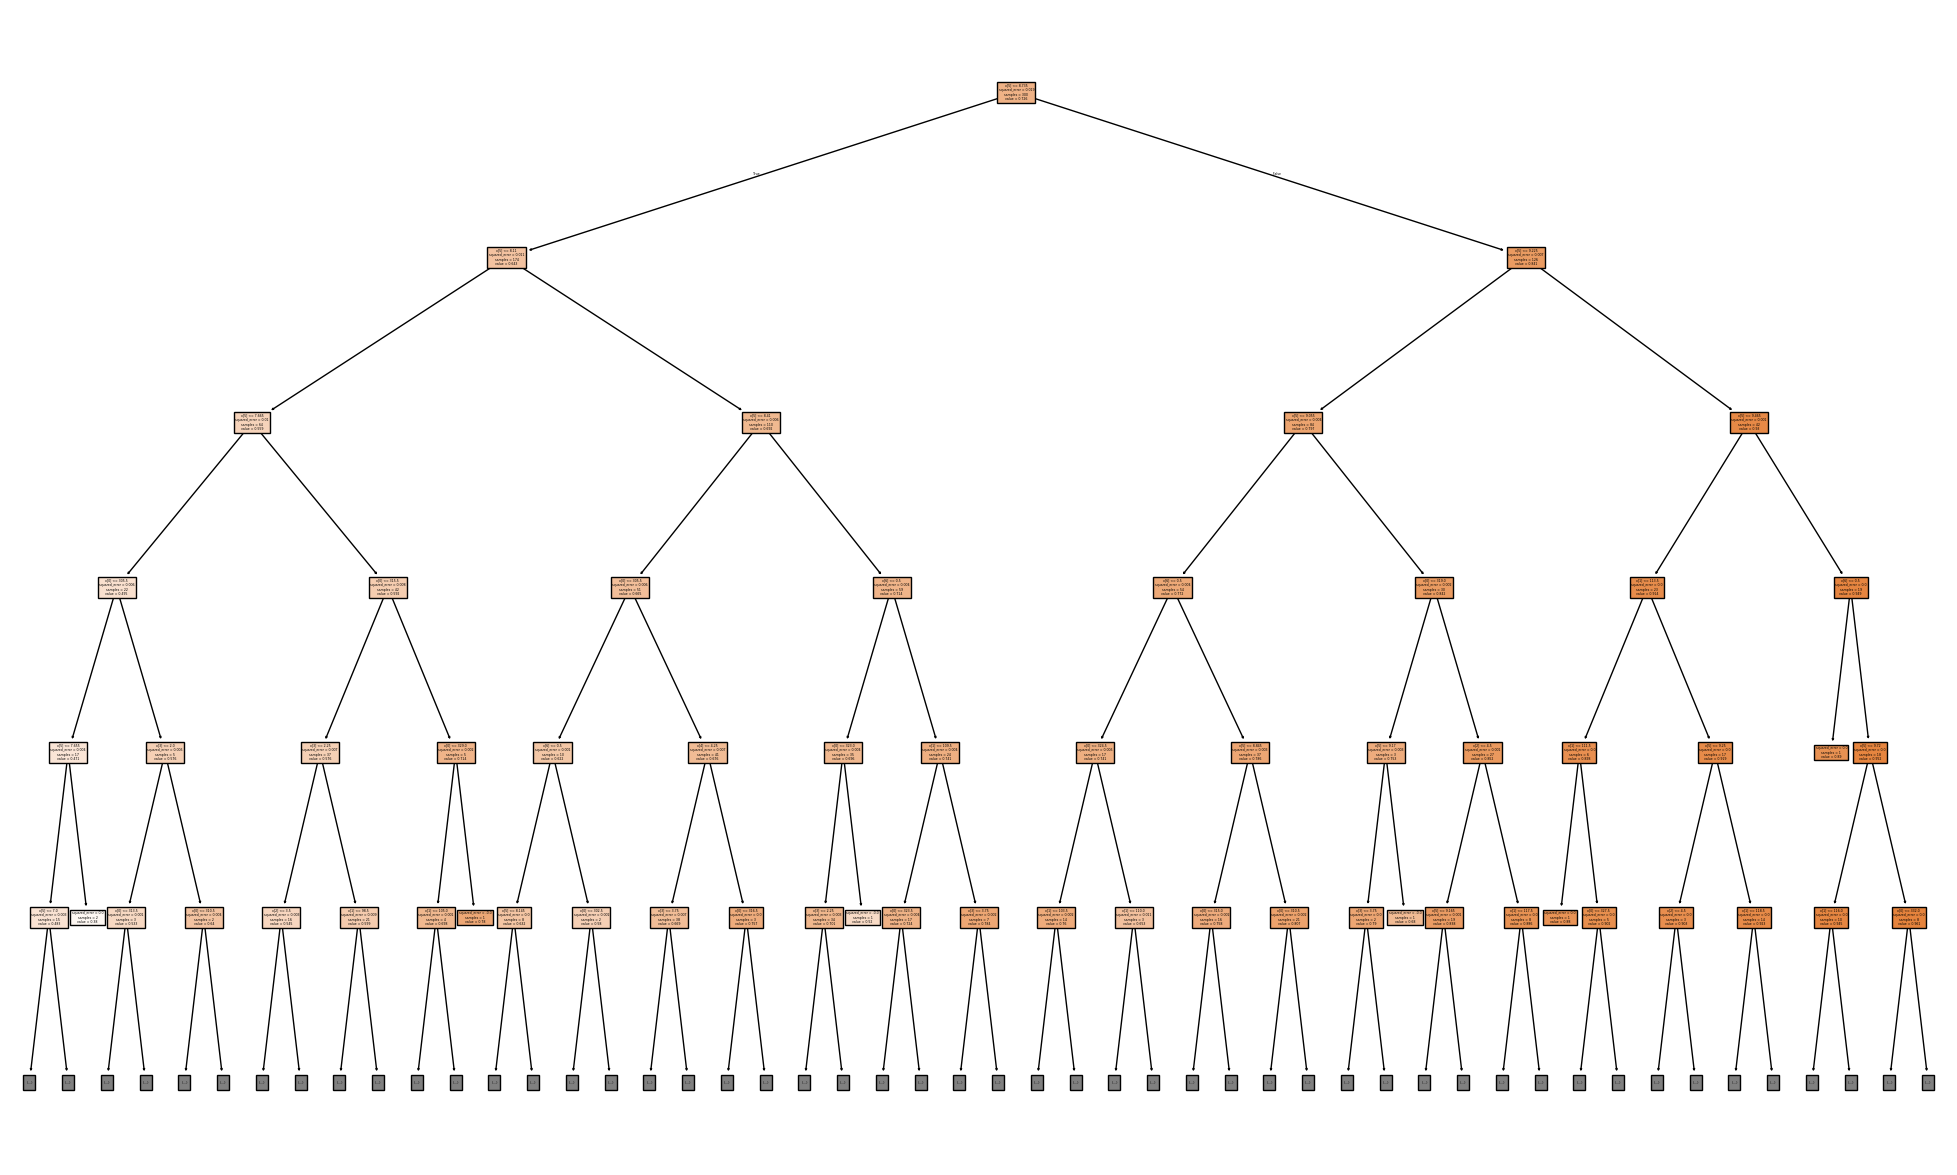

In [35]:
fig = plt.figure(figsize=(25,15))
tree.plot_tree(dt, filled = True,max_depth=5)  

In [36]:
import joblib

In [ ]:
joblib.dump(dt, "dt_model.pkl")

In [49]:
new_data = pd.DataFrame({
"GRE Score": [300, 270],
"TOEFL Score" : [144,120],  
"University Rating" : [6,7],      
"SOP"  : [6.5, 5.4],              
"LOR " :  [4.3, 7.2],                
"CGPA" :  [70.1,75.6] ,             
"Research" : [1, 0 ]           
})

In [50]:
new_data

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research
0,300,144,6,6.5,4.3,70.1,1
1,270,120,7,5.4,7.2,75.6,0


In [51]:
dt.predict(new_data)

array([0.94, 0.89])